# 小波分析

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 指定默认字体
plt.rcParams["axes.unicode_minus"] = False  # 解决保存图像是负号'-'显示为方块的问题

import scipy

import pywt

import xcw_package as xcw


## 0.导入数据

In [2]:
file_path="D:\那仁风电场偏航轴承数据/index.csv"
index=pd.read_csv(file_path,encoding="utf_8_sig")
index['故障类型'].value_counts()

故障类型
23#径向      60
3#径向       52
#38        32
3#径向10K    28
38#径向      24
38#轴向      16
Name: count, dtype: int64

In [3]:
sample_rate="25600Hz"
fault_type="#38"
measure_point="测点1"   
database=index[(index['采样频率']==sample_rate)&(index['故障类型']==fault_type)&(index['测点']==measure_point)]
database

,设备,测点,采样频率,日期,故障类型,文件路径
0,那仁10K,测点1,25600Hz,2023-10-18 11:19:25,#38,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_#38_T219e1865ddf测点...
1,那仁10K,测点1,25600Hz,2023-10-18 11:21:43,#38,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_#38_T219e1865ddf测点...
2,那仁10K,测点1,25600Hz,2023-10-18 11:27:49,#38,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_#38_T219e1865ddf测点...
3,那仁10K,测点1,25600Hz,2023-10-18 11:30:06,#38,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_#38_T219e1865ddf测点...
4,那仁10K,测点1,25600Hz,2023-10-18 11:35:42,#38,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_#38_T219e1865ddf测点...
5,那仁10K,测点1,25600Hz,2023-10-18 11:37:34,#38,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_#38_T219e1865ddf测点...
6,那仁10K,测点1,25600Hz,2023-10-18 11:40:50,#38,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_#38_T219e1865ddf测点...
7,那仁10K,测点1,25600Hz,2023-10-18 11:42:59,#38,D:\那仁风电场偏航轴承数据/时域波形数据\那仁10K_#38_T219e1865ddf测点...


信号长度: 1536000
采样频率: 25600.0 Hz
采样间隔: 0.000039 s
信号采样时长: 60.000 s
频谱频率分辨率: 0.017 Hz
可分析频率上限: 12800.0 Hz



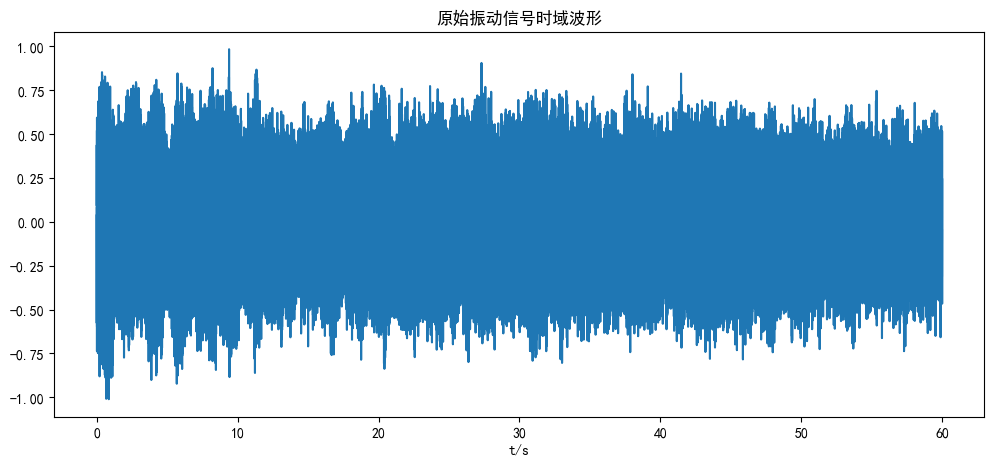

In [9]:
data=database.iloc[2]
data_path=data['文件路径']
# 读取文件
with open(data_path, 'r') as file:
    data_str = file.read()
    data_list = data_str.split(',')

# 将字符串数据转换为浮点数，并创建 NumPy 数组
data_array = np.array(data_list, dtype=float)
signal=xcw.Signal(data_array,f_s=25600)
signal.info()
signal.plot("原始振动信号时域波形")

## 1.时频分析

重采样

In [108]:
down_signal=xcw.resample(signal,new_f_s=4096,new_N=4096*60)

平均功率谱

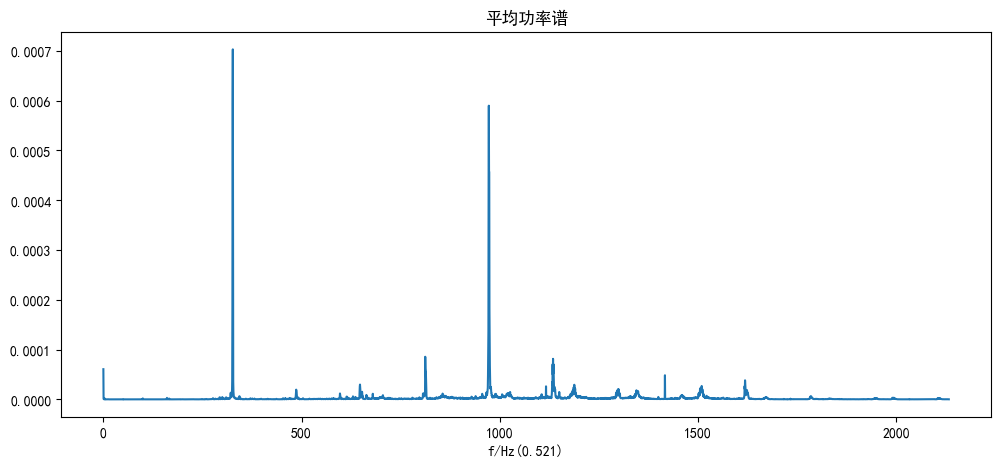

In [110]:
xcw.plot_powerspectrum(down_signal,nperseg=8192)

STFT时频图

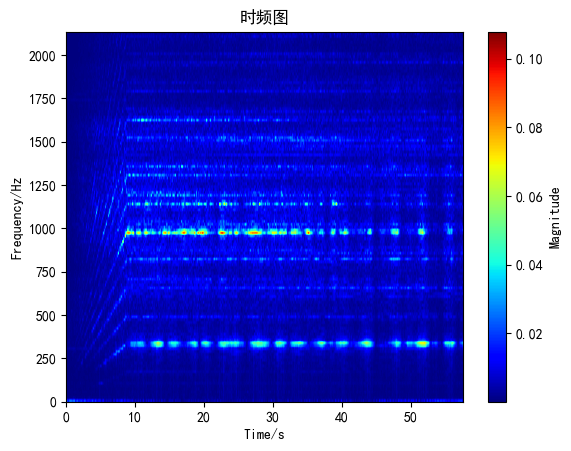

In [111]:
xcw.plot_stft(down_signal,256)

**时频图中在f=330Hz左右发现循环平稳因素，故分析此。首先截取出该频段**

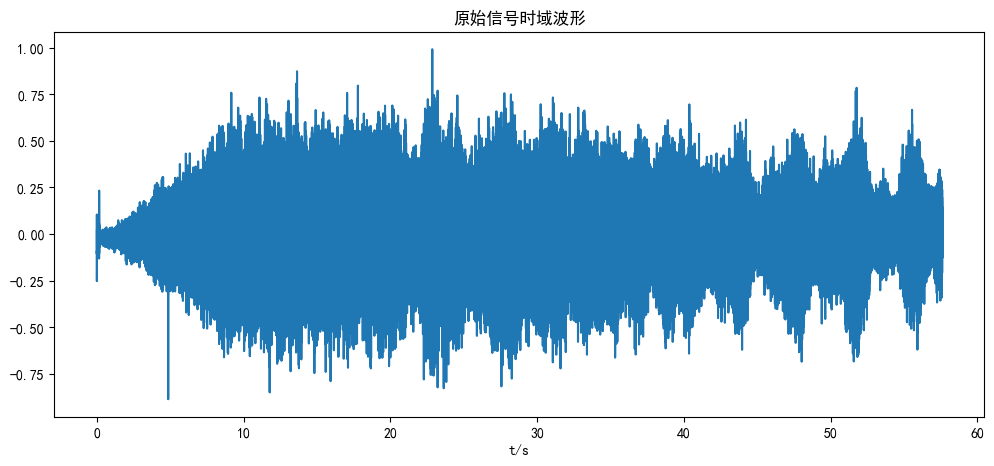

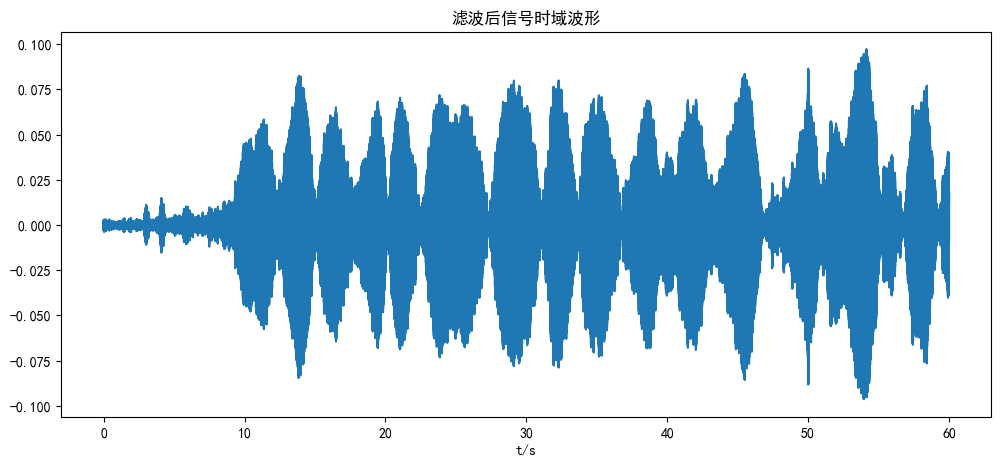

In [114]:
t = np.linspace(0,256*down_signal.dt,256, endpoint=False)
window = np.sin(2 * np.pi * 330 * t)

convolved = np.convolve(down_signal.data, window, mode='same')/256
filtered_signal=xcw.Signal(convolved,f_s=4096)
down_signal.plot("原始信号时域波形")
filtered_signal.plot("滤波后信号时域波形")

然后做适当包络处理

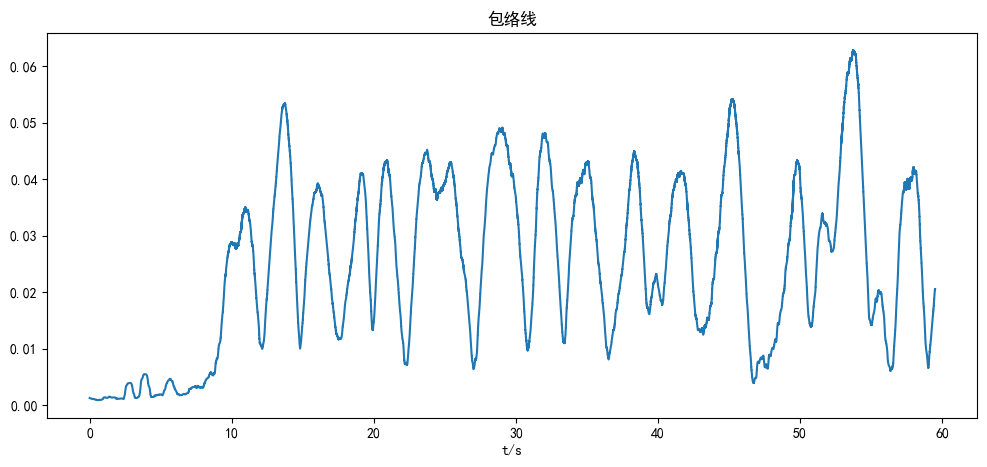

In [116]:
enve_signal=xcw.plot_movingwindow(filtered_signal,2048,np.std,title="包络线",result=True)
enve_signal=xcw.Signal(enve_signal,f_s=4096)

最后绘制频谱观察循环频率

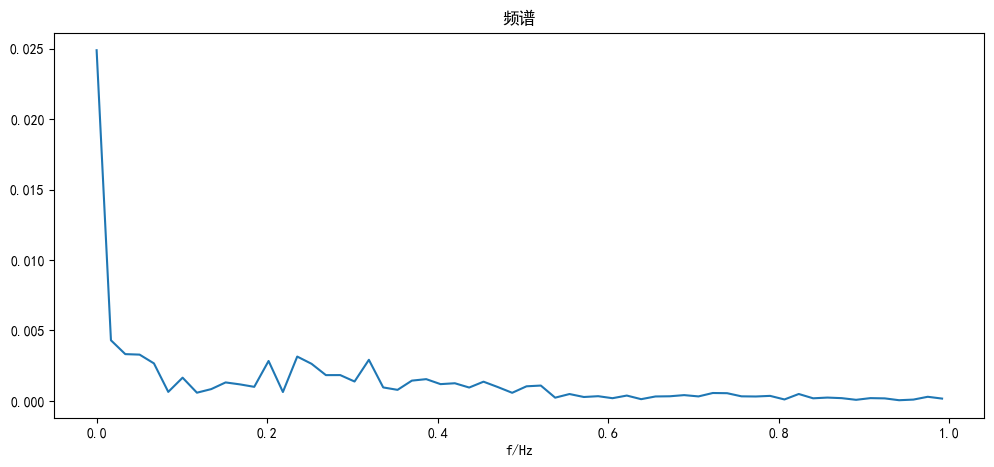

In [117]:
xcw.plot_fft(enve_signal,cutoff_f=1)

## 2.小波阈值去噪

### 2.1.小波分解

In [16]:
def Dwt(s,wavelet,result=False):
    data=s.data.copy()
    LPF,HPF=pywt.Wavelet(wavelet).filter_bank[:2]
    data=np.pad(data,len(LPF)//2,mode="symmetric")#首尾平拓展

    cA=np.convolve(data,LPF,mode="valid")[::2]#低通滤波和降采样
    cD=np.convolve(data,HPF,mode="valid")[::2]#高通滤波和降采样

    cA = cA[:-1]  
    cD = cD[:-1]  #保持长度为原始信号的一半

    time=s.t_values[::2]#降采样后的时间序列

    plt.figure(figsize=(12,10))
    plt.subplot(2,1,1)
    plt.plot(time,cD)
    plt.title("细节")
    plt.subplot(2,1,2)
    plt.plot(time,cA)
    plt.title("近似")
    plt.show()
    if result:
        return cA,cD
    else:
        return None

def Wavedec(s,wavelet,level,result=False):
    coeffs=[]#存放小波系数
    cA=s.data.copy()#初始化0层分解的cA

    for i in range(level):#进行level层分解
        cA,cD=pywt.dwt(cA,wavelet)#进行一层分解
        coeffs.append(cD)#频率由高到低的细节系数       
    coeffs.append(cA)#存储cA

    time=np.linspace(0,s.T,10)
    frequency=np.array((s.f_s/4,s.f_s/2))#小波系数的大致频率范围

    plt.figure(figsize=(12,5*(level+2)))
    plt.subplot(level+2,1,1)
    plt.plot(s.t_values,s.data)
    plt.title("原始信号")
    for i in range(level):
        time=np.linspace(0,s.T,len(coeffs[i]),endpoint=False)
        plt.subplot(level+2,1,i+2)
        plt.plot(time,coeffs[i])
        plt.title("第{}层细节:{}~{}Hz".format(i+1,frequency[0],frequency[1]))
        frequency/=2
    time=np.linspace(0,s.T,len(coeffs[level]),endpoint=False)
    plt.subplot(level+2,1,level+2)
    plt.plot(time,coeffs[level])
    plt.title("第{}层近似:{}~{}Hz".format(level,0,frequency[1]))
    plt.show()

    if result:
        return coeffs
    else:
        return None


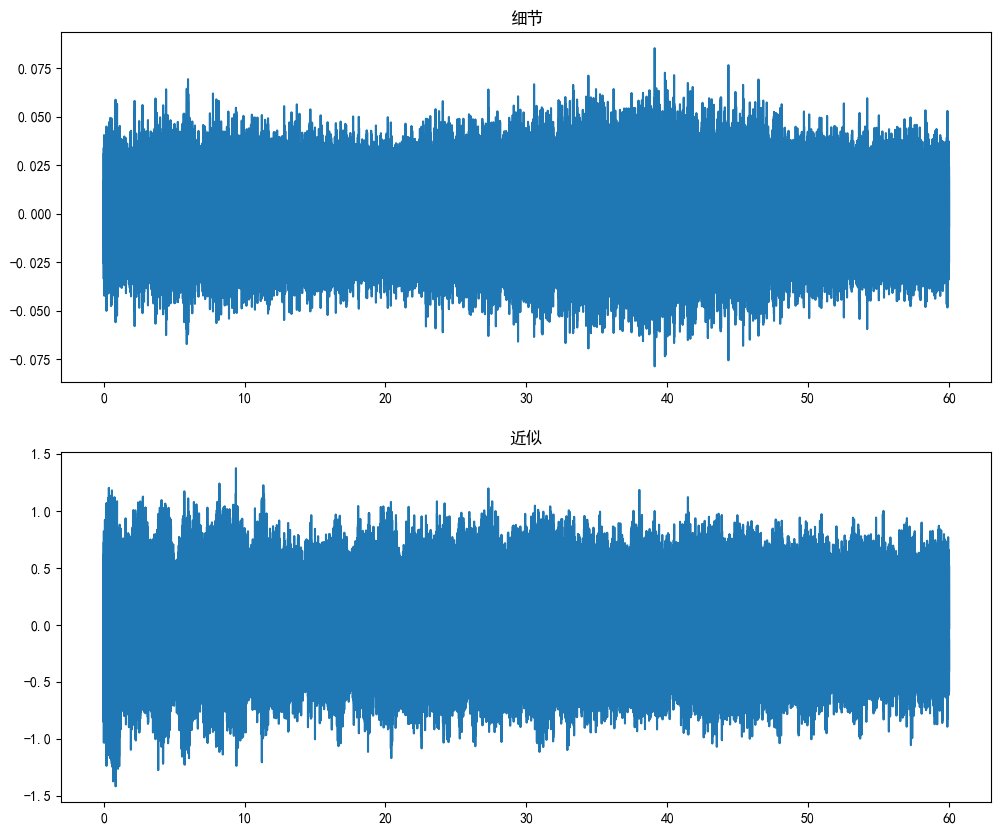

In [17]:
Dwt(signal,"db4")

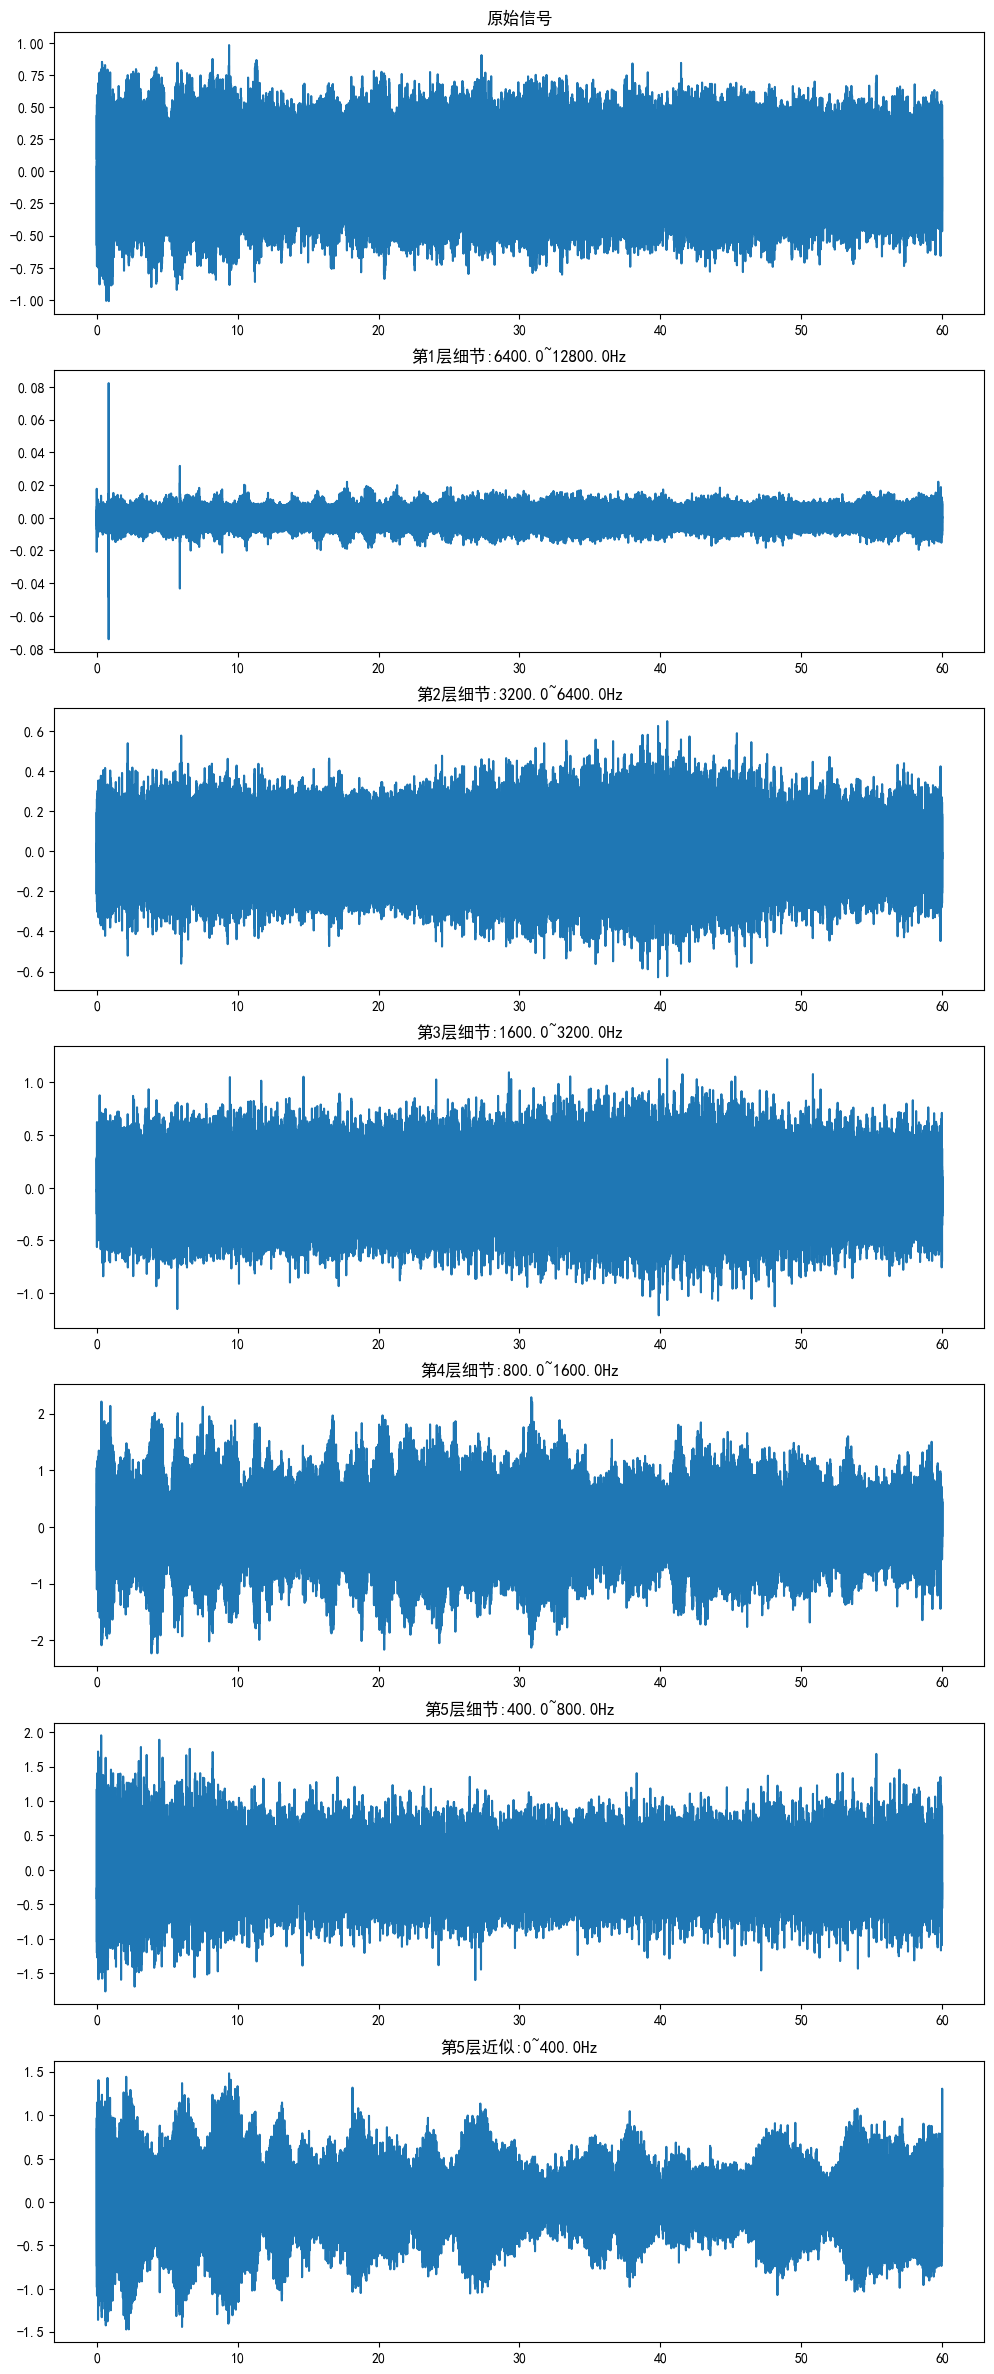

In [10]:
wavecoeffs=Wavedec(signal,"db20",level=5,result=True)

### 2.2.阈值化

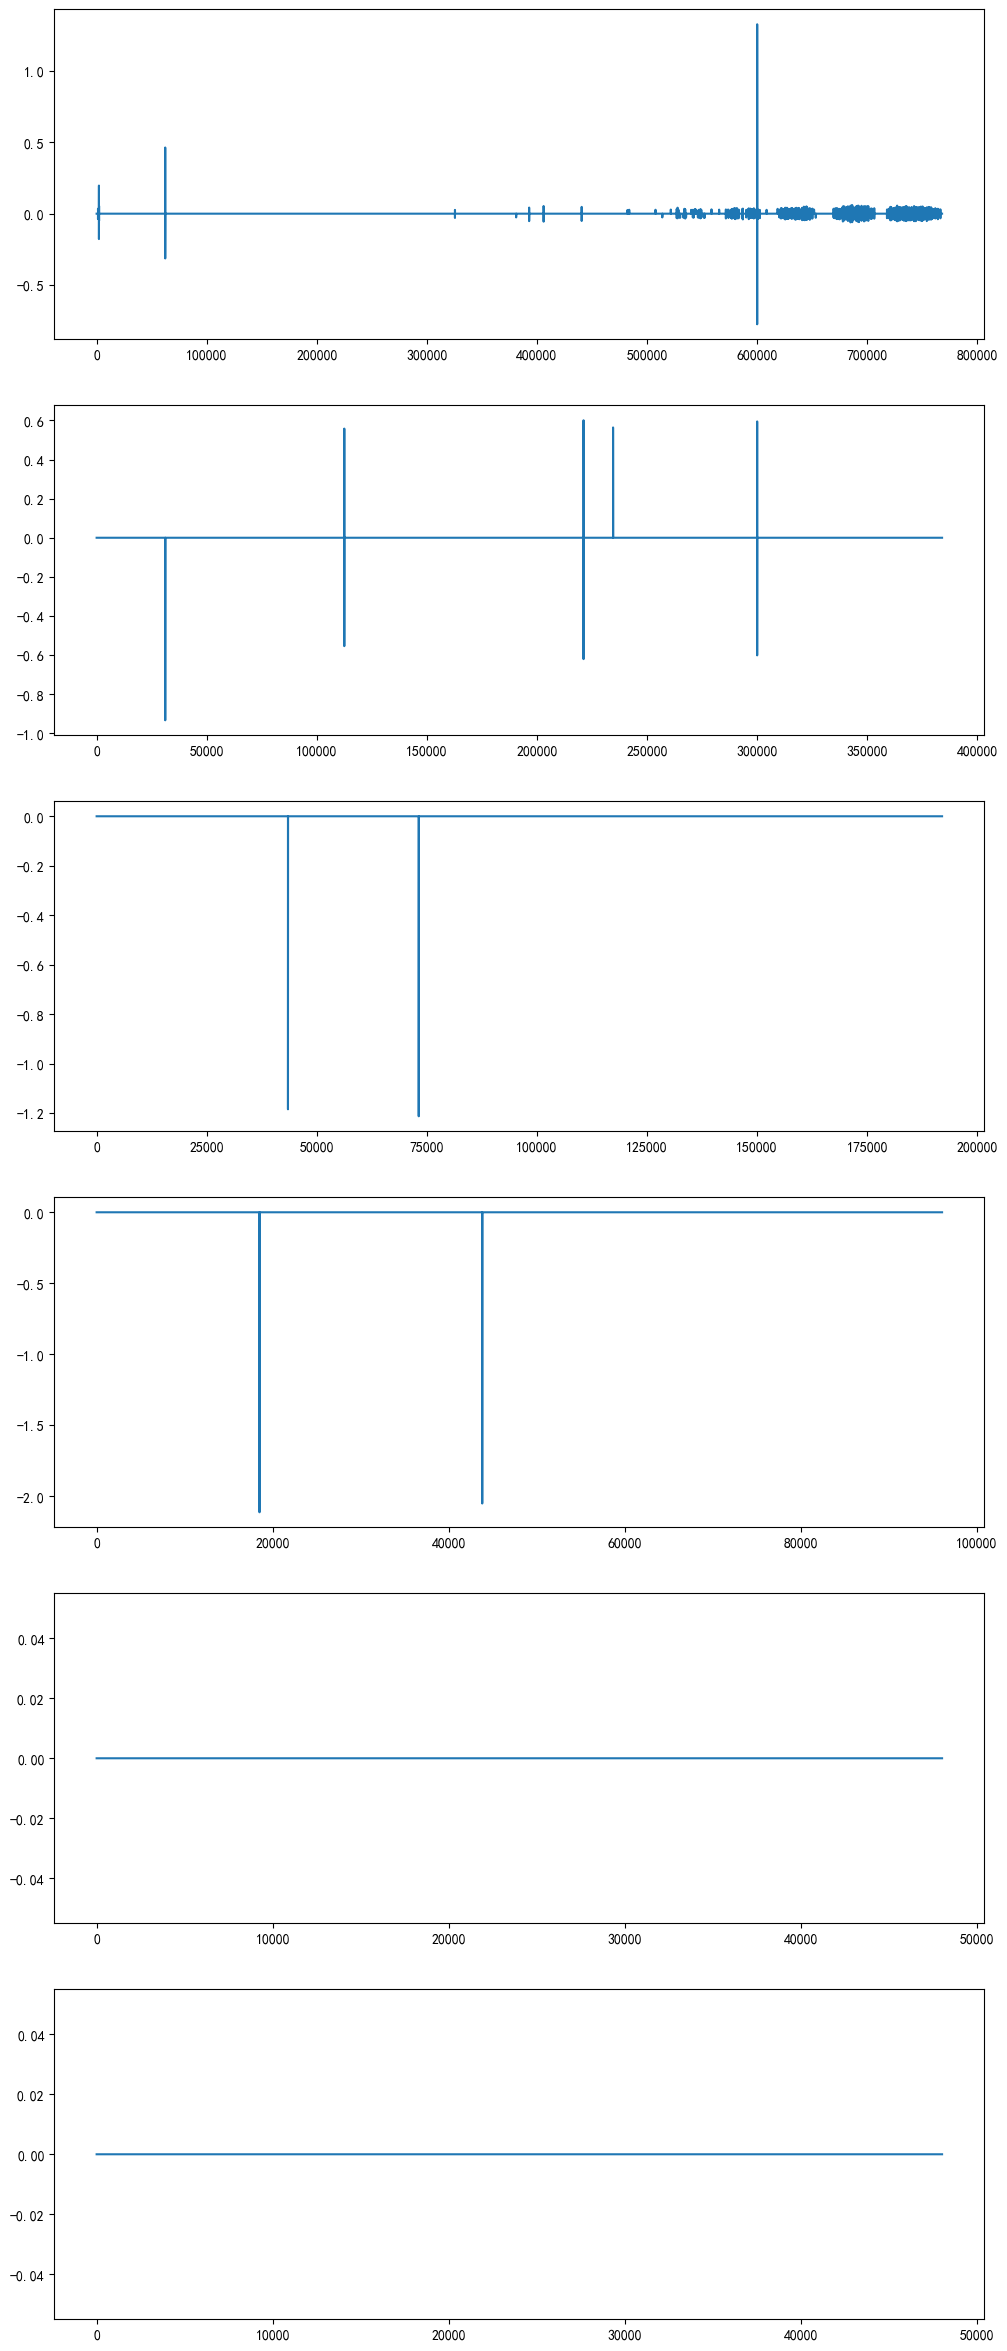

In [94]:
def threshold(data):
    return np.std(data)*np.sqrt(2*np.log(len(data)))

plt.figure(figsize=(12,5*6))
for i in range(6):
    wavecoeffs[i]=np.where(np.abs(wavecoeffs[i])<threshold(wavecoeffs[i]),0,wavecoeffs[i])#硬阈值处理
    plt.subplot(6,1,i+1)
    plt.plot(wavecoeffs[i])
    
plt.show()


### 2.3.信号重构

In [104]:
rec_signal=pywt.waverec(wavecoeffs[::-1],"db20")#小波重构
rec_signal=xcw.Signal(rec_signal,f_s=25600)

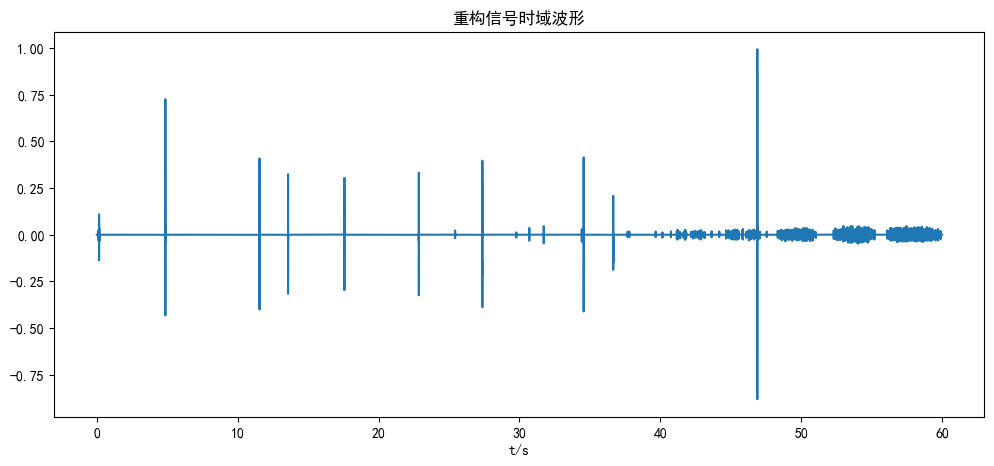

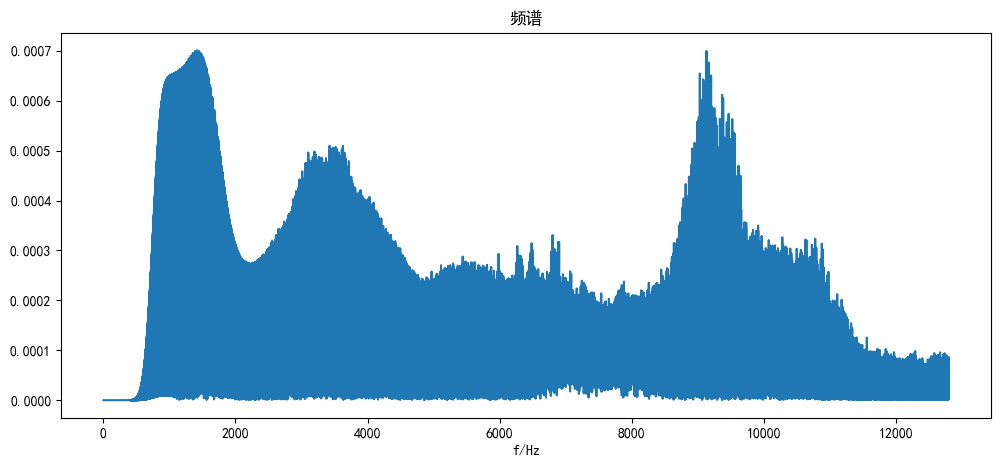

In [107]:
rec_signal.plot("重构信号时域波形")
xcw.plot_fft(rec_signal,density=True)